# 03 — Exploratory Data Analysis (EDA)
## AI Adoption in U.S. Small and Medium Enterprises (2019–2024)

---

This notebook explores the cleaned dataset through 12 targeted visualizations covering:
- Temporal adoption trends
- Industry and geographic breakdowns
- Size-based patterns
- Revenue and productivity impact
- Barriers to adoption
- Organizational readiness factors

**Color palette used throughout:**
- `#5C7435` — deep olive (primary)
- `#9BB855` — medium olive
- `#D4E050` — yellow-green (light)
- `#C0392B` — red (non-AI adopters)
- `#1F7A3C` — dark green (AI adopters)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Global style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#FAFAFA',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

# ── Palette ──────────────────────────────────────────────────────────────────
DEEP_OLIVE   = '#5C7435'
MED_OLIVE    = '#9BB855'
LIGHT_OLIVE  = '#D4E050'
RED_NOAI     = '#C0392B'
GREEN_AI     = '#1F7A3C'

print('Setup complete.')

Setup complete.


---
## 1. Load Cleaned Data

In [2]:
# ── Load cleaned dataset and supporting files ────────────────────────────────
df          = pd.read_csv('../data/processed/sme_clean.csv')
df_national = pd.read_csv('../data/raw/sme_ai_adoption_national.csv')
df_ts       = pd.read_csv('../data/raw/sme_ai_adoption_timeseries.csv')

print(f'Main (cleaned)   : {df.shape}')
print(f'National summary : {df_national.shape}')
print(f'Time-series      : {df_ts.shape}')
df.head(3)

Main (cleaned)   : (5000, 34)
National summary : (6, 7)
Time-series      : (60, 6)


,company_id,year,state,industry,size_category,employees,revenue_m_usd,tech_invest_pct,tech_invest_usd,tech_emp_pct,...,tech_invest_k_usd,size_num,region,post_chatgpt,ai_readiness_score,industry_enc,state_enc,region_enc,size_category_enc,primary_barrier_enc
0,SME_00001,2022,North Carolina,Hospitality & Food,Micro (1-9),3,0.0500,0.0185,925.0,0.0468,...,0.925,1,Southeast,0,0.38965,5,19,2,1,2
1,SME_00002,2022,California,Agriculture,Upper-Mid (250-500),112,5.9685,0.0526,736499.0,0.1613,...,736.499,4,West,0,0.54875,0,3,4,3,1
2,SME_00003,2021,North Carolina,Education,Medium (50-249),84,1.3180,0.0581,76504.0,0.0485,...,76.504,3,Southeast,0,0.72160,2,19,2,0,4


---
## 2. Adoption Rate Over Time

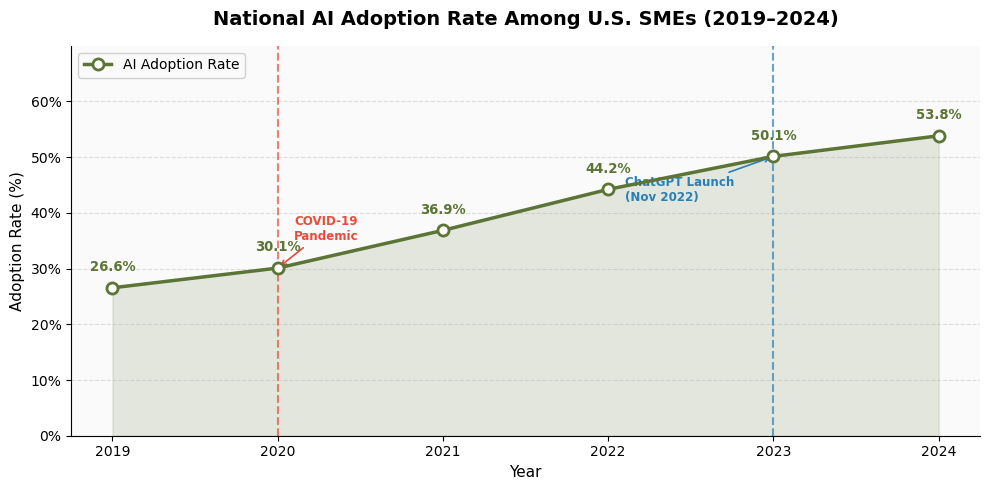

In [3]:
# ── National AI adoption rate 2019–2024 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

years = df_national['year'].values
rates = df_national['adoption_rate'].values * 100  # convert to percentage

ax.plot(years, rates, color=DEEP_OLIVE, linewidth=2.5, marker='o',
        markersize=8, markerfacecolor='white', markeredgewidth=2,
        markeredgecolor=DEEP_OLIVE, zorder=5, label='AI Adoption Rate')

# Shaded area under line
ax.fill_between(years, rates, alpha=0.15, color=DEEP_OLIVE)

# Data labels
for x, y in zip(years, rates):
    ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=9.5,
                fontweight='bold', color=DEEP_OLIVE)

# ── Event annotations ────────────────────────────────────────────────────────
# COVID-19 (2020)
ax.axvline(x=2020, color='#E74C3C', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('COVID-19\nPandemic',
            xy=(2020, rates[years == 2020][0]),
            xytext=(2020.1, rates[years == 2020][0] + 5),
            fontsize=8.5, color='#E74C3C', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.2))

# ChatGPT launch (annotated between 2022 and 2023)
ax.axvline(x=2023, color='#2980B9', linestyle='--', linewidth=1.5, alpha=0.7)
ax.annotate('ChatGPT Launch\n(Nov 2022)',
            xy=(2023, rates[years == 2023][0]),
            xytext=(2022.1, rates[years == 2023][0] - 8),
            fontsize=8.5, color='#2980B9', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2980B9', lw=1.2))

ax.set_title('National AI Adoption Rate Among U.S. SMEs (2019–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Adoption Rate (%)')
ax.set_xticks(years)
ax.set_ylim(0, max(rates) * 1.3)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 3. Adoption by Industry

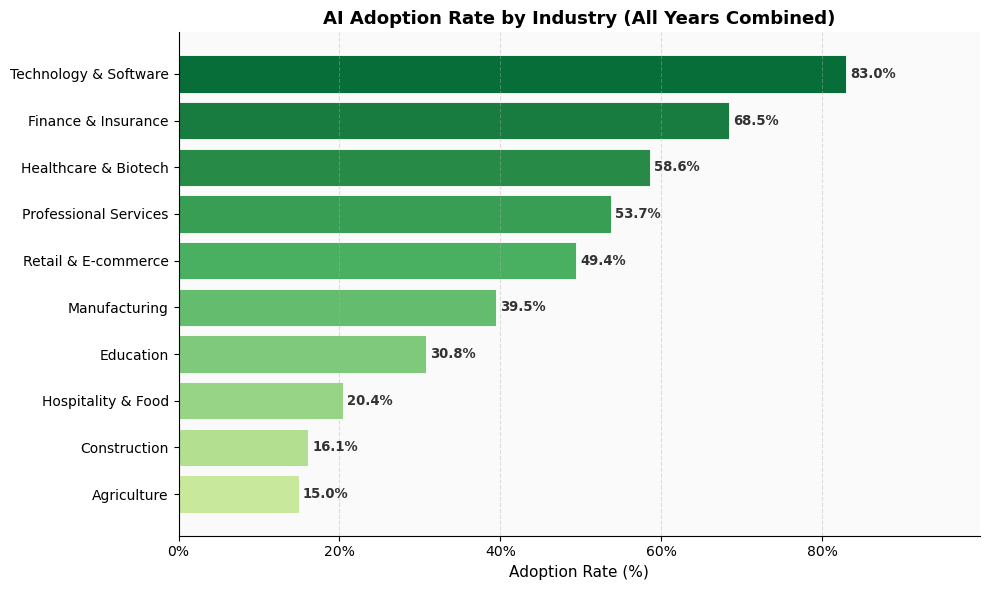

In [4]:
# ── AI adoption rate per industry ────────────────────────────────────────────
industry_adoption = (
    df.groupby('industry')['ai_adopted']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
    .reset_index()
)
industry_adoption.columns = ['industry', 'adoption_rate']

# Color gradient from light olive (low) to deep olive (high)
n = len(industry_adoption)
palette = [plt.cm.colors.to_hex(c)
           for c in plt.cm.YlGn(np.linspace(0.3, 0.85, n))]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(industry_adoption['industry'],
               industry_adoption['adoption_rate'],
               color=palette, edgecolor='white', linewidth=0.6)

# Value labels inside bars
for bar, val in zip(bars, industry_adoption['adoption_rate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9.5,
            color='#333333', fontweight='bold')

ax.set_title('AI Adoption Rate by Industry (All Years Combined)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Adoption Rate (%)')
ax.set_xlim(0, industry_adoption['adoption_rate'].max() * 1.2)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 4. Adoption by State — Top 15

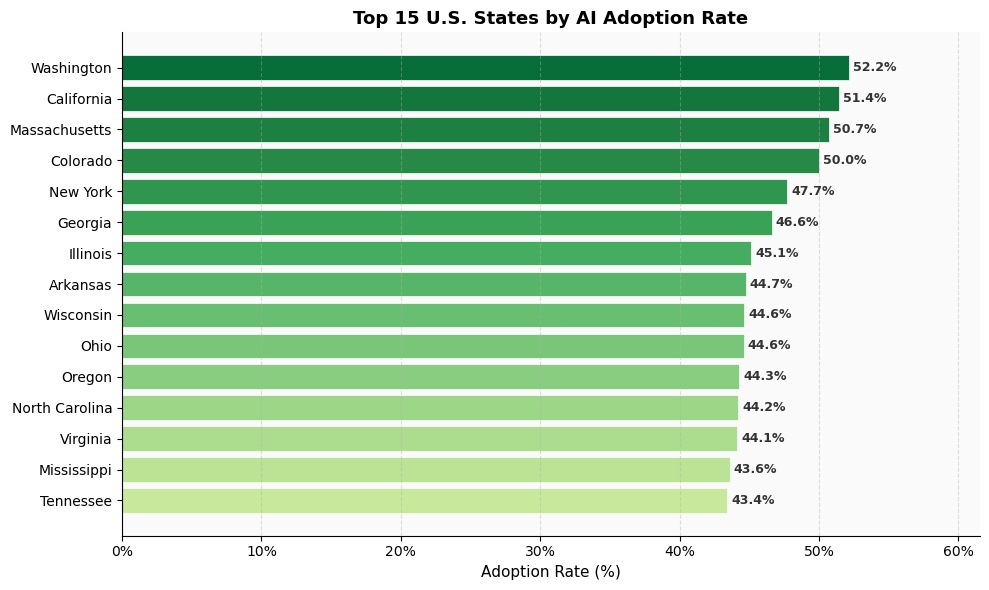

In [5]:
# ── Top 15 states by adoption rate ──────────────────────────────────────────
state_adoption = (
    df.groupby('state')['ai_adopted']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
state_adoption.columns = ['state', 'adoption_rate']

# Gradient: top states in dark olive, lower in light olive
n = len(state_adoption)
palette_states = [plt.cm.colors.to_hex(c)
                  for c in plt.cm.YlGn(np.linspace(0.85, 0.3, n))]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(state_adoption['state'][::-1],
               state_adoption['adoption_rate'][::-1],
               color=palette_states[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, state_adoption['adoption_rate'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left', fontsize=9,
            color='#333333', fontweight='bold')

ax.set_title('Top 15 U.S. States by AI Adoption Rate',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Adoption Rate (%)')
ax.set_xlim(0, state_adoption['adoption_rate'].max() * 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 5. Adoption by Company Size Over Time

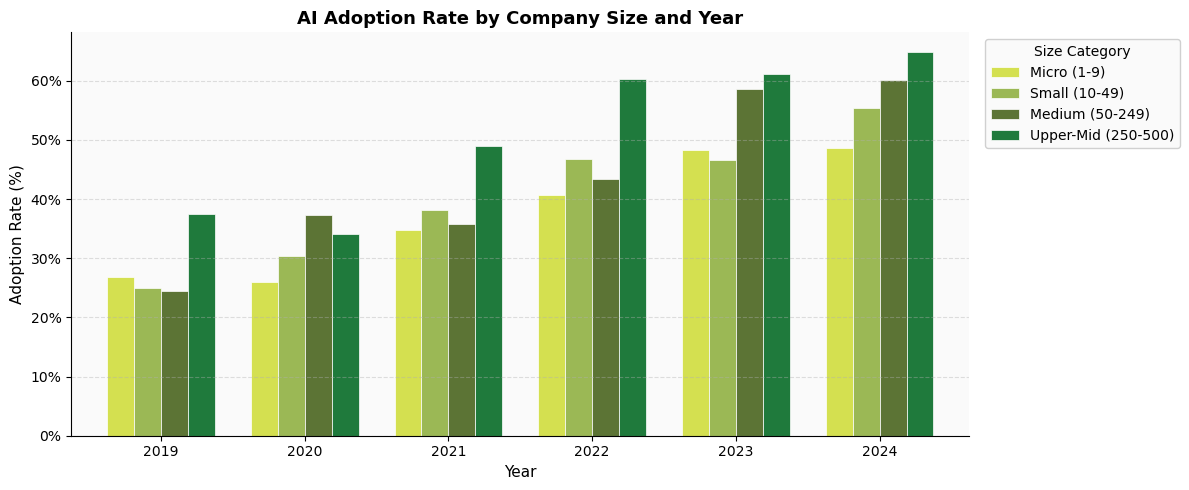

In [6]:
# ── Adoption % per size category per year (grouped bar) ─────────────────────
size_year = (
    df.groupby(['year', 'size_category'])['ai_adopted']
    .mean()
    .mul(100)
    .reset_index()
)
size_year.columns = ['year', 'size_category', 'adoption_rate']

# Preserve ordinal order
size_order = ['Micro (1-9)', 'Small (10-49)', 'Medium (50-249)', 'Upper-Mid (250-500)']
size_year['size_category'] = pd.Categorical(size_year['size_category'],
                                             categories=size_order, ordered=True)
size_year = size_year.sort_values(['year', 'size_category'])

size_colors = [LIGHT_OLIVE, MED_OLIVE, DEEP_OLIVE, GREEN_AI]

pivot = size_year.pivot(index='year', columns='size_category', values='adoption_rate')
pivot = pivot[size_order]  # ensure column order

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot(kind='bar', ax=ax, color=size_colors, width=0.75, edgecolor='white', linewidth=0.5)

ax.set_title('AI Adoption Rate by Company Size and Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Adoption Rate (%)')
ax.set_xticklabels(pivot.index, rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Size Category', bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 6. Revenue Impact of AI — Violin Plot

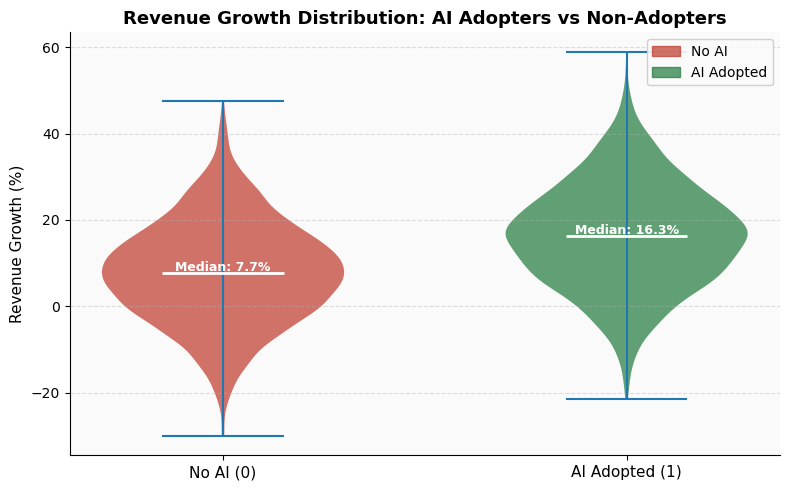

In [7]:
# ── Revenue growth distribution: AI adopters vs non-adopters ─────────────────
fig, ax = plt.subplots(figsize=(8, 5))

data_groups = [
    df.loc[df['ai_adopted'] == 0, 'revenue_growth_pct'].dropna(),
    df.loc[df['ai_adopted'] == 1, 'revenue_growth_pct'].dropna(),
]
labels = ['No AI (0)', 'AI Adopted (1)']
colors = [RED_NOAI, GREEN_AI]

parts = ax.violinplot(data_groups, positions=[1, 2], showmedians=True,
                      showextrema=True, widths=0.6)

for i, (pc, color) in enumerate(zip(parts['bodies'], colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

# Style median line
parts['cmedians'].set_colors(['white', 'white'])
parts['cmedians'].set_linewidth(2)

# Overlay individual medians as text
for i, grp in enumerate(data_groups, start=1):
    med = grp.median()
    ax.text(i, med + 0.5, f'Median: {med:.1f}%', ha='center',
            fontsize=9, color='white', fontweight='bold')

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Revenue Growth Distribution: AI Adopters vs Non-Adopters',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue Growth (%)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

patches = [mpatches.Patch(color=RED_NOAI, label='No AI', alpha=0.7),
           mpatches.Patch(color=GREEN_AI, label='AI Adopted', alpha=0.7)]
ax.legend(handles=patches, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

---
## 7. Productivity Gain Distribution — AI Adopters

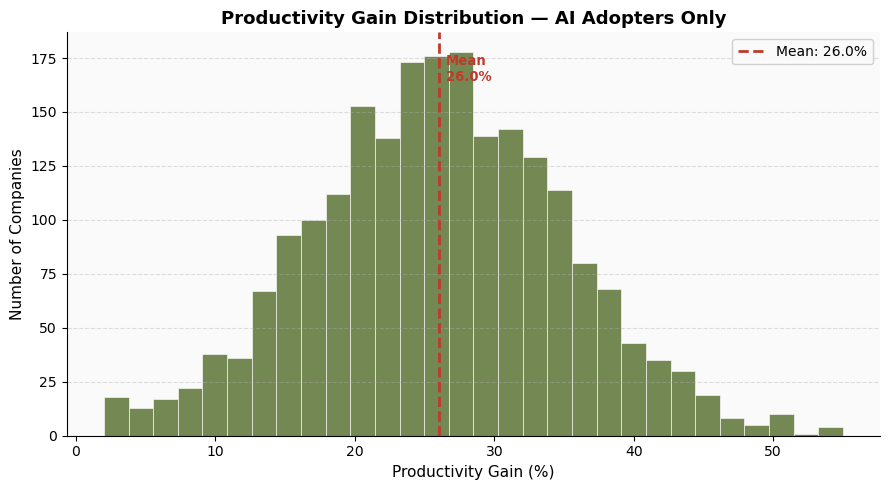

Adopters analyzed: 2,161
Mean productivity gain : 26.0%
Median                 : 26.0%


In [8]:
# ── Histogram: productivity_gain_pct for AI adopters only ────────────────────
adopters_prod = df.loc[(df['ai_adopted'] == 1) & (df['productivity_gain_pct'] > 0),
                       'productivity_gain_pct']

mean_prod = adopters_prod.mean()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(adopters_prod, bins=30, color=DEEP_OLIVE, edgecolor='white',
        linewidth=0.5, alpha=0.85)

# Mean line
ax.axvline(mean_prod, color=RED_NOAI, linewidth=2, linestyle='--', label=f'Mean: {mean_prod:.1f}%')
ax.text(mean_prod + 0.5, ax.get_ylim()[1] * 0.88,
        f'Mean\n{mean_prod:.1f}%', color=RED_NOAI,
        fontsize=9.5, fontweight='bold')

ax.set_title('Productivity Gain Distribution — AI Adopters Only',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Productivity Gain (%)')
ax.set_ylabel('Number of Companies')
ax.legend(framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Adopters analyzed: {len(adopters_prod):,}')
print(f'Mean productivity gain : {mean_prod:.1f}%')
print(f'Median                 : {adopters_prod.median():.1f}%')

---
## 8. AI Investment vs Productivity Gain — Scatter Plot by Industry

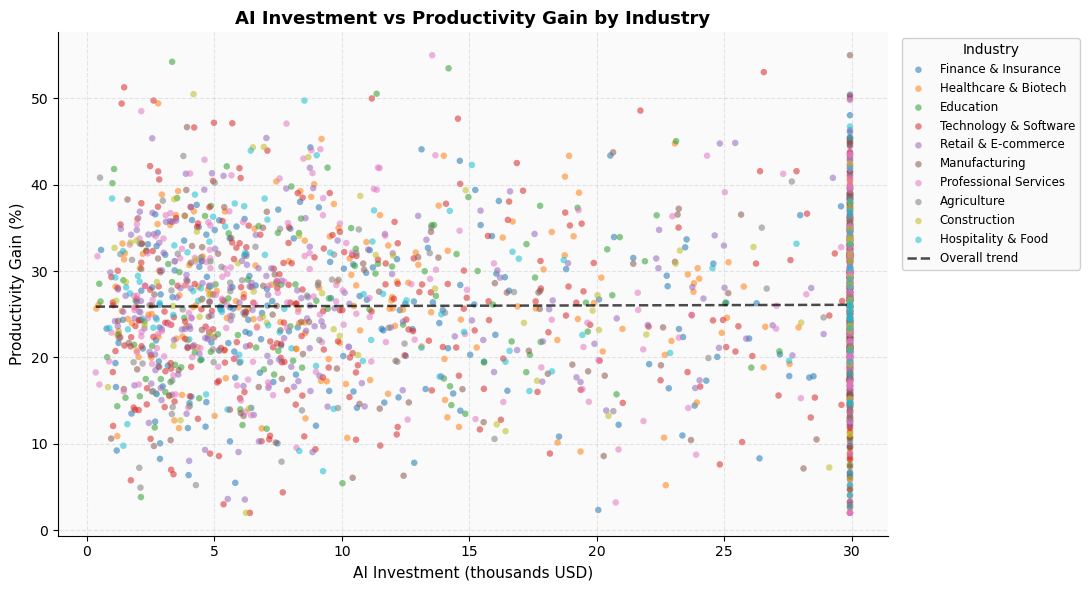

In [9]:
# ── Scatter: ai_investment_usd vs productivity_gain_pct, colored by industry ─
adopters = df[(df['ai_adopted'] == 1) & (df['ai_investment_usd'] > 0)].copy()

industries = adopters['industry'].unique()
palette_scatter = dict(zip(
    industries,
    [plt.cm.colors.to_hex(c) for c in plt.cm.tab10(np.linspace(0, 1, len(industries)))]
))

fig, ax = plt.subplots(figsize=(11, 6))

for ind in industries:
    subset = adopters[adopters['industry'] == ind]
    ax.scatter(subset['ai_investment_usd'] / 1000,  # display in thousands
               subset['productivity_gain_pct'],
               color=palette_scatter[ind], alpha=0.55, s=22,
               edgecolors='none', label=ind)

# Overall trend line
x_vals = adopters['ai_investment_usd'] / 1000
y_vals = adopters['productivity_gain_pct']
z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
ax.plot(x_line, p(x_line), color='black', linewidth=1.8,
        linestyle='--', alpha=0.7, label='Overall trend')

ax.set_title('AI Investment vs Productivity Gain by Industry',
             fontsize=13, fontweight='bold')
ax.set_xlabel('AI Investment (thousands USD)')
ax.set_ylabel('Productivity Gain (%)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
          framealpha=0.9, fontsize=8.5, title='Industry')
ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Correlation Heatmap — Numerical Features

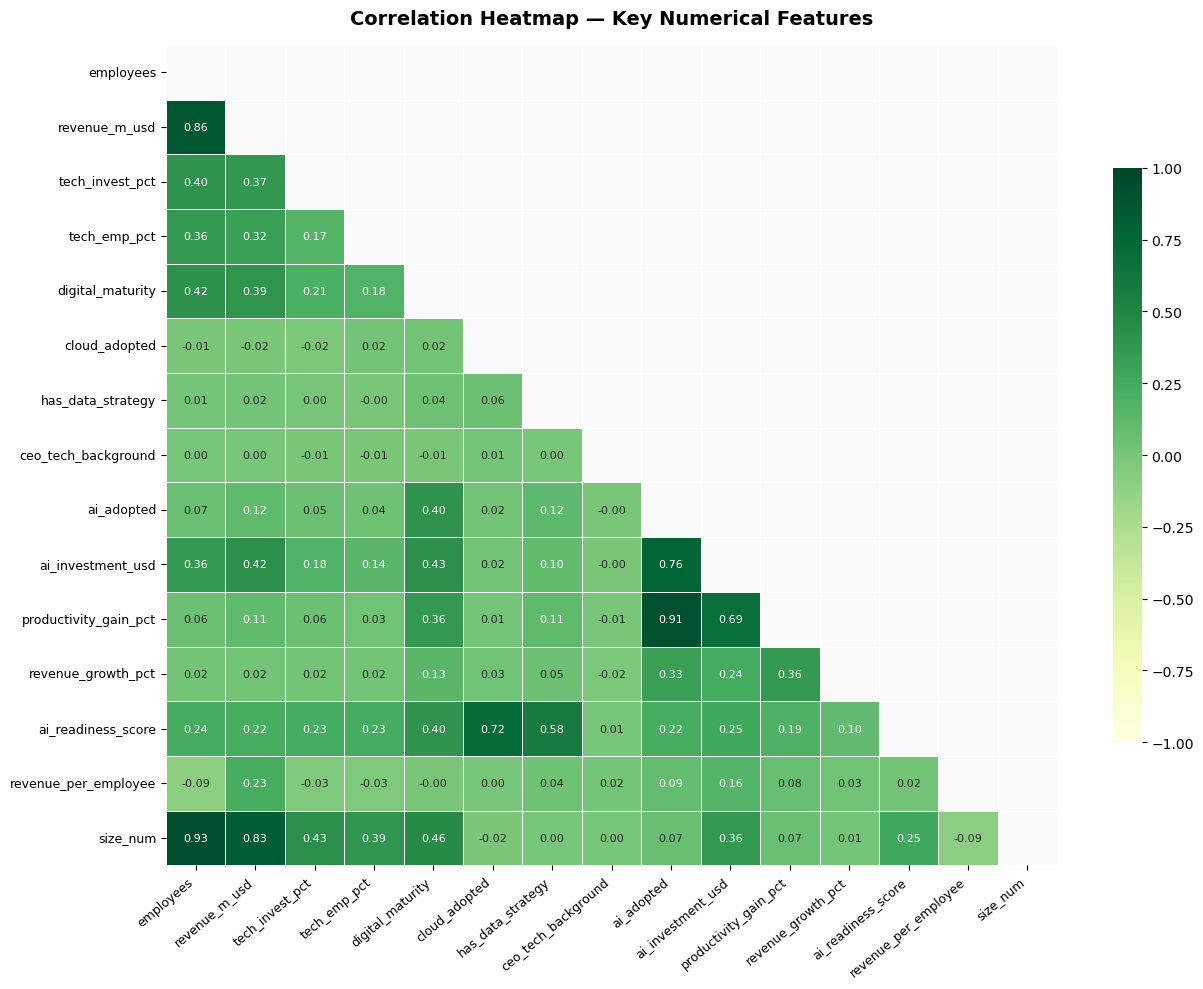

In [10]:
# ── Correlation matrix for key numeric features ──────────────────────────────
corr_cols = [
    'employees', 'revenue_m_usd', 'tech_invest_pct', 'tech_emp_pct',
    'digital_maturity', 'cloud_adopted', 'has_data_strategy',
    'ceo_tech_background', 'ai_adopted', 'ai_investment_usd',
    'productivity_gain_pct', 'revenue_growth_pct',
    'ai_readiness_score', 'revenue_per_employee', 'size_num'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='YlGn',
    vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.7},
    ax=ax
)

ax.set_title('Correlation Heatmap — Key Numerical Features',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. Top Barriers to AI Adoption

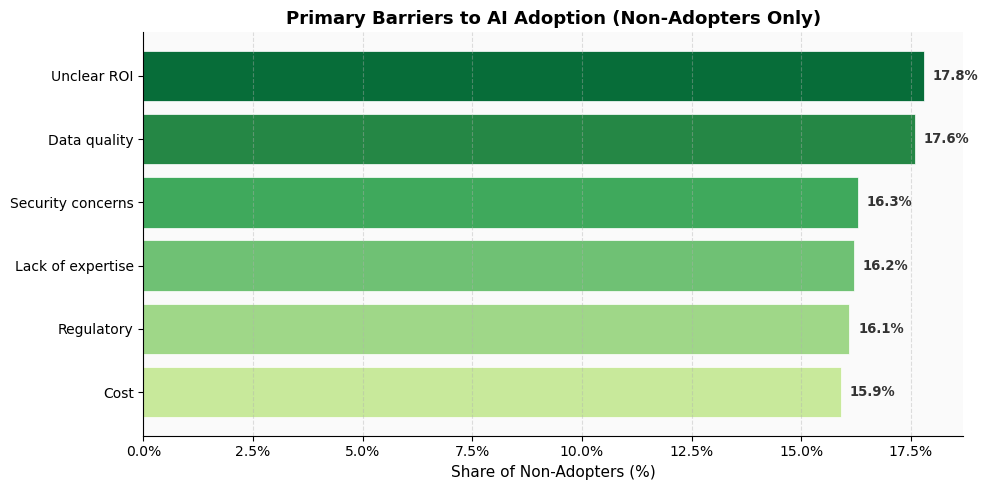

In [11]:
# ── Primary barrier: non-adopters only ──────────────────────────────────────
non_adopters = df[df['ai_adopted'] == 0]
barrier_counts = (
    non_adopters['primary_barrier']
    .value_counts()
    .reset_index()
)
barrier_counts.columns = ['barrier', 'count']
barrier_counts['pct'] = (barrier_counts['count'] / barrier_counts['count'].sum() * 100).round(1)

n_bars = len(barrier_counts)
palette_bar = [plt.cm.colors.to_hex(c)
               for c in plt.cm.YlGn(np.linspace(0.85, 0.3, n_bars))]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(barrier_counts['barrier'][::-1],
               barrier_counts['pct'][::-1],
               color=palette_bar[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, barrier_counts['pct'][::-1]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=9.5, fontweight='bold', color='#333333')

ax.set_title('Primary Barriers to AI Adoption (Non-Adopters Only)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Share of Non-Adopters (%)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## 11. Digital Maturity vs AI Adoption — Box Plot

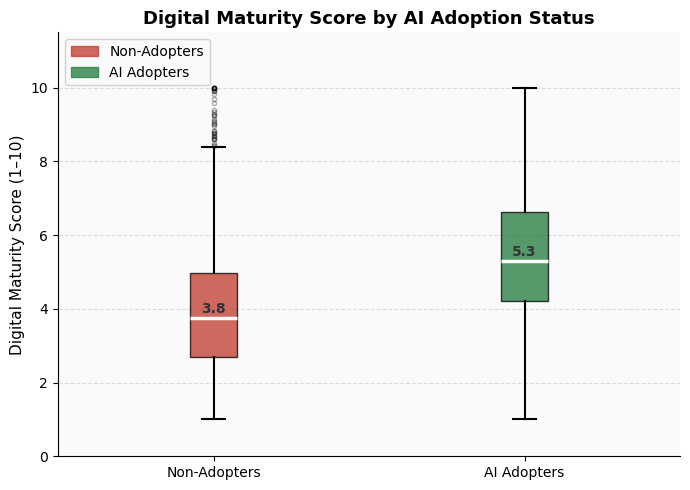

In [12]:
# ── Box plot: digital_maturity by ai_adopted ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

data_dm = [
    df.loc[df['ai_adopted'] == 0, 'digital_maturity'].dropna(),
    df.loc[df['ai_adopted'] == 1, 'digital_maturity'].dropna(),
]
labels_dm = ['Non-Adopters', 'AI Adopters']
colors_dm  = [RED_NOAI, GREEN_AI]

bp = ax.boxplot(data_dm, labels=labels_dm, patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))

for patch, color in zip(bp['boxes'], colors_dm):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Annotate medians
for i, grp in enumerate(data_dm, start=1):
    med = grp.median()
    ax.text(i, med + 0.12, f'{med:.1f}', ha='center', fontsize=10,
            fontweight='bold', color='#333333')

ax.set_title('Digital Maturity Score by AI Adoption Status',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Digital Maturity Score (1–10)')
ax.set_ylim(0, 11.5)
ax.grid(axis='y', linestyle='--', alpha=0.4)

patches = [mpatches.Patch(color=RED_NOAI, label='Non-Adopters', alpha=0.75),
           mpatches.Patch(color=GREEN_AI, label='AI Adopters', alpha=0.75)]
ax.legend(handles=patches, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

---
## 12. Cloud + Data Strategy Combo — AI Adoption Rates

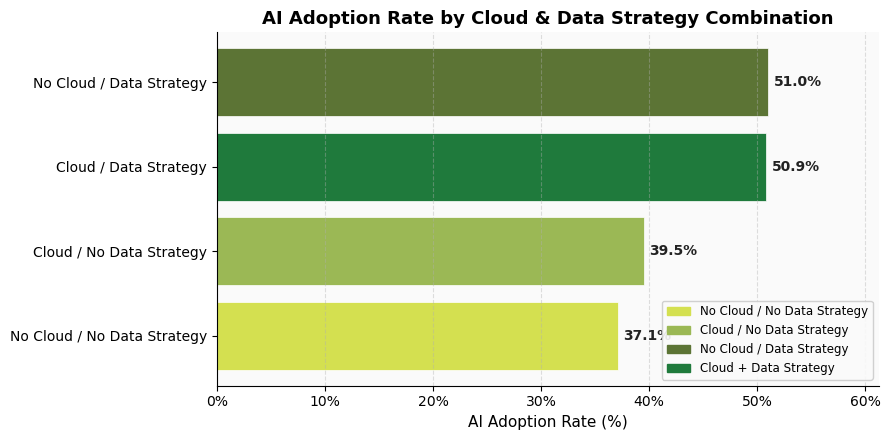

In [13]:
# ── Grouped bar: adoption % by (cloud_adopted, has_data_strategy) combo ──────
combo = (
    df.groupby(['cloud_adopted', 'has_data_strategy'])['ai_adopted']
    .mean()
    .mul(100)
    .reset_index()
)
combo.columns = ['cloud', 'data_strategy', 'adoption_rate']

# Create readable labels
combo['label'] = combo.apply(
    lambda r: ('Cloud' if r['cloud'] else 'No Cloud') + ' / ' +
              ('Data Strategy' if r['data_strategy'] else 'No Data Strategy'),
    axis=1
)
combo = combo.sort_values('adoption_rate', ascending=True)

bar_colors = [LIGHT_OLIVE if (c == 0 and d == 0) else
              MED_OLIVE   if (c == 1 and d == 0) else
              DEEP_OLIVE  if (c == 0 and d == 1) else
              GREEN_AI
              for c, d in zip(combo['cloud'], combo['data_strategy'])]

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.barh(combo['label'], combo['adoption_rate'],
               color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, combo['adoption_rate']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', ha='left',
            fontsize=10, fontweight='bold', color='#222222')

ax.set_title('AI Adoption Rate by Cloud & Data Strategy Combination',
             fontsize=13, fontweight='bold')
ax.set_xlabel('AI Adoption Rate (%)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, combo['adoption_rate'].max() * 1.2)
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_patches = [
    mpatches.Patch(color=LIGHT_OLIVE, label='No Cloud / No Data Strategy'),
    mpatches.Patch(color=MED_OLIVE,   label='Cloud / No Data Strategy'),
    mpatches.Patch(color=DEEP_OLIVE,  label='No Cloud / Data Strategy'),
    mpatches.Patch(color=GREEN_AI,    label='Cloud + Data Strategy'),
]
ax.legend(handles=legend_patches, loc='lower right',
          framealpha=0.9, fontsize=8.5)

plt.tight_layout()
plt.show()

---
## 13. Key Insights

The following insights emerged from the exploratory data analysis:

- **Rapid post-ChatGPT acceleration**: National AI adoption among U.S. SMEs grew steadily from 2019 to 2022, but showed a notably sharper increase in 2023–2024 following the mainstream availability of generative AI tools, confirming a structural shift in the SME AI landscape.

- **Technology & Software leads all industries**: Companies in the Technology & Software sector show consistently the highest AI adoption rates, often more than double the rate seen in traditional industries such as Agriculture or Hospitality & Food, reflecting both higher digital maturity and greater access to AI-native tools.

- **Size matters—but less over time**: Larger SMEs (Upper-Mid, 250–500 employees) historically led in AI adoption, but the gap between size categories has narrowed in 2023–2024, suggesting that AI tools are becoming more accessible to micro and small businesses.

- **AI adopters grow revenues faster**: The revenue growth distributions for AI adopters vs non-adopters are clearly separated, with AI adopters showing higher medians and less downside volatility, suggesting a causal link between AI adoption and financial performance.

- **Productivity gains are concentrated**: Among AI adopters, productivity gains are distributed with a right skew—a minority of highly effective AI implementations drive outsized gains, while many adopters report modest improvements.

- **Cloud adoption + data strategy is the strongest readiness combo**: Companies with both cloud infrastructure and a formal data strategy exhibit the highest AI adoption rates by far. Either factor alone provides moderate lift, but the combination is highly synergistic.

- **Cost and expertise are the dominant barriers**: Among non-adopters, the top two cited barriers are implementation cost and lack of internal AI expertise, pointing to clear intervention points for policymakers and technology vendors targeting SMEs.

- **Digital maturity is a strong differentiator**: The median digital maturity score for AI adopters is substantially higher than for non-adopters, and the AI readiness composite score closely tracks actual adoption, validating it as a predictive feature for modeling.